# Sistem Rekomendasi Resep Makanan

## Pengantar Dataset

Dataset yang digunakan pada project ini adalah Food.com Recipes and Interactions yang bersumber dari platform Food.com dan tersedia melalui Kaggle. Dataset ini berisi lebih dari 230.000 data resep makanan dengan berbagai atribut seperti nama resep, durasi memasak, tags, kandungan nutrisi, jumlah langkah memasak, deskripsi, daftar bahan, dan jumlah bahan. Dataset dipilih karena memiliki jumlah data yang besar, struktur data yang lengkap, serta relevan untuk pengembangan sistem rekomendasi resep makanan berdasarkan karakteristik bahan, waktu memasak, dan informasi nutrisi. Dari sisi etika penggunaan, dataset ini merupakan data publik dan tidak memuat identitas pribadi pengguna, namun tetap memiliki potensi bias karena berasal dari satu platform resep tertentu sehingga preferensi makanan yang ditampilkan dapat lebih merepresentasikan pengguna Food.com.

## Pre Processing Data

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np

In [9]:
df = pd.read_csv("RAW_recipes.csv")

In [10]:
interactions = pd.read_csv("RAW_interactions.csv")

#### Cek struktur dataset

##### dataset recipes

In [11]:
print("Jumlah data:", df.shape)
print("\nData awal:")
df.head(2)

Jumlah data: (231637, 12)

Data awal:


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6


In [12]:
print(df.dtypes)

name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object


##### dataset interaction

In [13]:
print("Jumlah data:", interactions.shape)
print("\nData awal:")
interactions.head(2)

Jumlah data: (1132367, 5)

Data awal:


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."


In [14]:
print(interactions.dtypes)

user_id       int64
recipe_id     int64
date         object
rating        int64
review       object
dtype: object


#### Data cleaning

##### dataset recipes

In [15]:
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [16]:
df.dropna(
    subset=["name"],
    inplace=True
)

df["description"] = df[
    "description"
].fillna(
    "No description"
)

In [17]:
df.isnull().sum()

name              0
id                0
minutes           0
contributor_id    0
submitted         0
tags              0
nutrition         0
n_steps           0
steps             0
description       0
ingredients       0
n_ingredients     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

##### dataset interaction

In [19]:
interactions.isnull().sum()

user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

In [20]:
interactions["review"] = interactions[
    "review"
].fillna(
    "No review"
)

In [21]:
interactions.isnull().sum()

user_id      0
recipe_id    0
date         0
rating       0
review       0
dtype: int64

In [22]:
interactions.duplicated().sum()

np.int64(0)

##### save dataset clean

In [23]:
df.to_csv("dataset_clean.csv", index=False)

#### Parsing
Pada dataset recipes, terdapat kolom yang menyimpan data dalam bentuk string. Jika diproses, python akan menganggapnya sebagai karakter biasa dan tidak dapat membaca angka angka gizi atau jumlah bahan di dalamnya.

In [24]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [25]:
df["nutrition"] = df[
    "nutrition"
].apply(
    ast.literal_eval
)

df["ingredients"] = df[
    "ingredients"
].apply(
    ast.literal_eval
)

df["tags"] = df[
    "tags"
].apply(
    ast.literal_eval
)

df["steps"] = df[
    "steps"
].apply(
    ast.literal_eval
)

In [26]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


---

#### EDA
Exploratory Data Analysis (EDA) dilakukan untuk mengenali karakterisitik sebaran data, mendeteksi outliers, serta melihat hubungan antar fitur sebelum data di training

##### analisis dataset recipes

In [27]:
print("Jumlah data:", df.shape)
df.describe()

Jumlah data: (231636, 12)


,id,minutes,contributor_id,n_steps,n_ingredients
count,231636.000000,2.316360e+05,2.316360e+05,231636.000000,231636.000000
mean,222014.077639,9.398587e+03,5.534906e+06,9.765516,9.051149
std,141206.613497,4.461973e+06,9.979162e+07,5.995136,3.734803
min,38.000000,0.000000e+00,2.700000e+01,0.000000,1.000000
25%,99943.750000,2.000000e+01,5.690500e+04,6.000000,6.000000
50%,207248.500000,4.000000e+01,1.736140e+05,9.000000,9.000000
75%,333815.250000,6.500000e+01,3.982750e+05,12.000000,11.000000
max,537716.000000,2.147484e+09,2.002290e+09,145.000000,43.000000


Terdapat 4 fitur numerik, yaitu `minutes`, `n_ingredient`, `n_step`, dan `rating`.

<Axes: xlabel='minutes', ylabel='Count'>

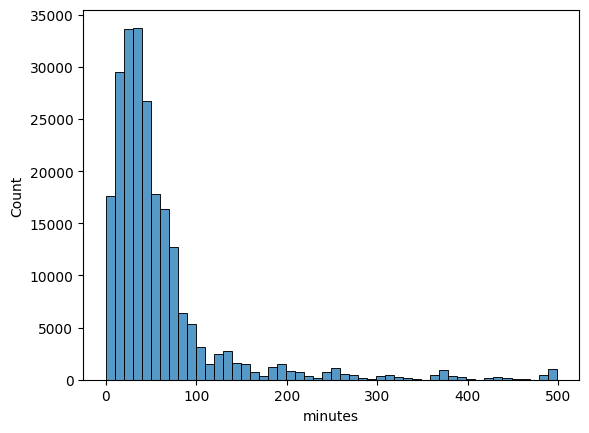

In [28]:
sns.histplot(
    df[df["minutes"] < 500]["minutes"],
    bins=50
)

<Axes: xlabel='n_ingredients', ylabel='Count'>

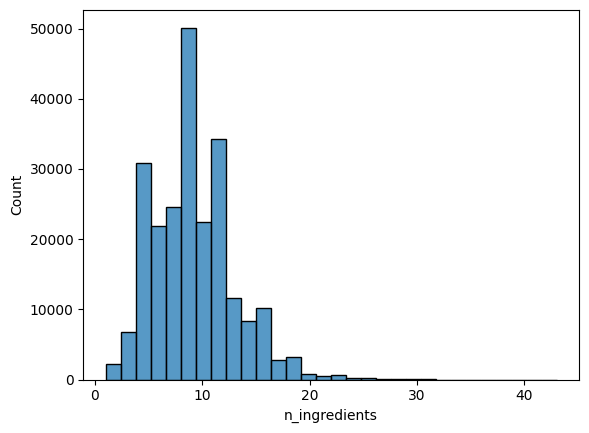

In [29]:
sns.histplot(
    df["n_ingredients"],
    bins=30
)

<Axes: xlabel='n_steps', ylabel='Count'>

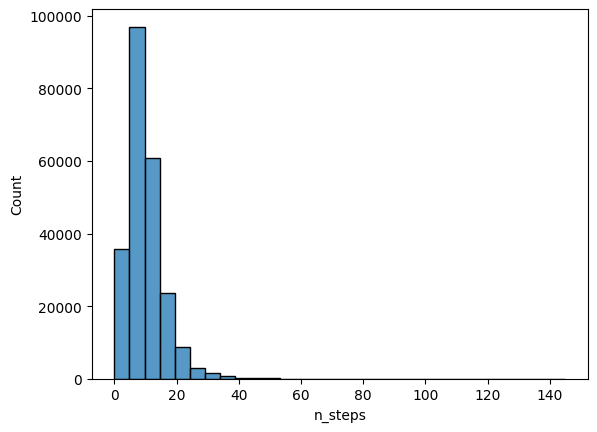

In [30]:
sns.histplot(df["n_steps"], bins=30)

Selanjutnya, dilakukan proses validasi data konkret menggunakan perintah pengurutan (.sort_values()) untuk memverifikasi nilai-resep paling ekstrem di batas bawah dan batas atas dataset—yaitu memeriksa apakah resep dengan durasi 0 menit murni merupakan hidangan mentah (seperti jus atau salad) dan resep dengan 43 bahan memang logis di dunia nyata

In [31]:
df[
    ["name","minutes"]
].sort_values(
    by="minutes"
).head(10)

,name,minutes
67883,cucumber dill dip,0
67871,cucumber cocktail,0
67817,cucumber and avocado salad,0
215787,tortilla beef,0
46713,chicken zucchini casserole,0
187900,six layer dinner,0
17796,barbecued garlic shrimp,0
17770,barbecued chicken thighs au vin,0
17665,barbecue sauce 1,0
17895,barbecued turkey on a bun,0


In [32]:
df[
    ["name","n_ingredients"]
].sort_values(
    by="n_ingredients",
    ascending=False
).head(10)

,name,n_ingredients
2162,a to z bread,43
230245,z best two faced jerk,40
139659,morton thompson turkey,40
116744,kato s garage style tomato sauce meatba...,39
18352,basic fried rice with variations,38
203614,sunday supper taco salad bowls tacos,37
119626,land and sea white meat version of surf and turf,37
71669,dhansak with brown rice,36
55542,coconut chicken fingers with mango rum salsa,35
105723,hillbilly bean soup,35


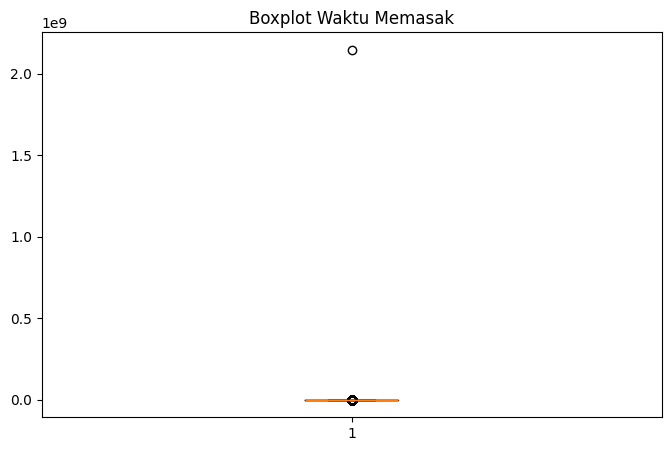

In [33]:
# boxplot
plt.figure(figsize=(8,5))

plt.boxplot(
    df["minutes"]
)

plt.title("Boxplot Waktu Memasak")

plt.show()

In [34]:
df["minutes"].describe(
    percentiles=[0.90,0.95,0.99]
)

count    2.316360e+05
mean     9.398587e+03
std      4.461973e+06
min      0.000000e+00
50%      4.000000e+01
90%      1.350000e+02
95%      2.550000e+02
99%      9.039500e+02
max      2.147484e+09
Name: minutes, dtype: float64

In [35]:
q99 = df["minutes"].quantile(0.99)

print(q99)

903.9499999999825


In [40]:
df["minutes"] = np.where(
    df["minutes"] > q99,
    q99,
    df["minutes"]
)

In [41]:
df["minutes"].describe(
    percentiles=[0.90,0.95,0.99]
)

count    231636.000000
mean         71.550356
std         123.134994
min           0.000000
50%          40.000000
90%         135.000000
95%         255.000000
99%         903.267500
max         903.950000
Name: minutes, dtype: float64

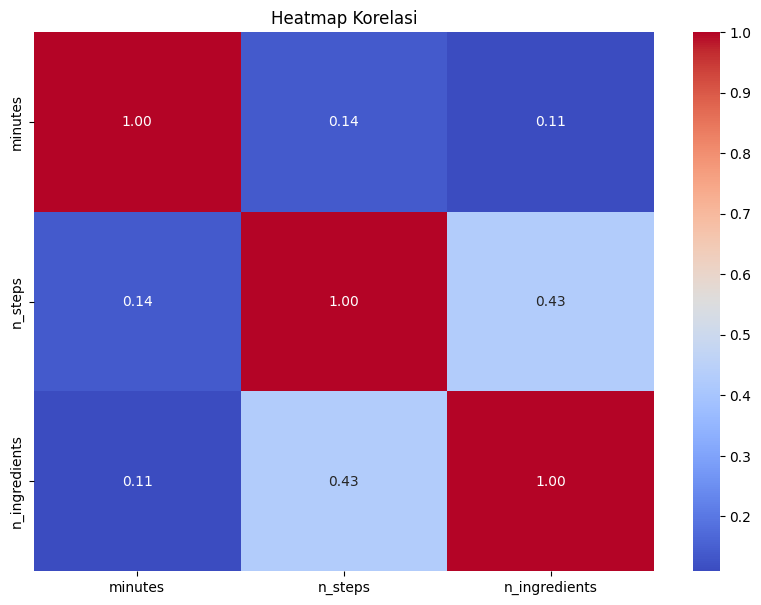

In [43]:
numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Heatmap Korelasi"
)

plt.show()

##### analisis dataset interaction

In [44]:
#struktur dataset
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   user_id    1132367 non-null  int64 
 1   recipe_id  1132367 non-null  int64 
 2   date       1132367 non-null  object
 3   rating     1132367 non-null  int64 
 4   review     1132367 non-null  object
dtypes: int64(3), object(2)
memory usage: 43.2+ MB


In [45]:
#statistik
print("Jumlah data:", interactions.shape)
interactions.describe()

Jumlah data: (1132367, 5)


,user_id,recipe_id,rating
count,1.132367e+06,1.132367e+06,1.132367e+06
mean,1.384291e+08,1.608972e+05,4.411016e+00
std,5.014269e+08,1.303987e+05,1.264752e+00
min,1.533000e+03,3.800000e+01,0.000000e+00
25%,1.354700e+05,5.425700e+04,4.000000e+00
50%,3.309370e+05,1.205470e+05,5.000000e+00
75%,8.045500e+05,2.438520e+05,5.000000e+00
max,2.002373e+09,5.377160e+05,5.000000e+00


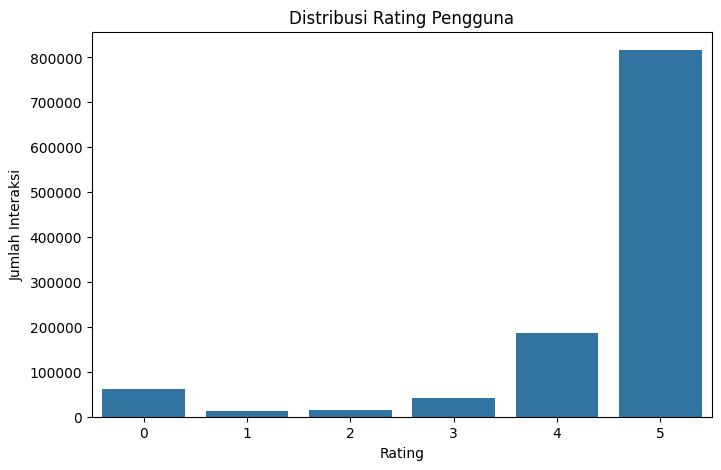

In [46]:
# distribusi rating
plt.figure(figsize=(8,5))

sns.countplot(
    x="rating",
    data=interactions
)

plt.title("Distribusi Rating Pengguna")
plt.xlabel("Rating")
plt.ylabel("Jumlah Interaksi")

plt.show()

In [47]:
# jumlah user dan recipe
print(
    "Jumlah User:",
    interactions["user_id"].nunique()
)

print(
    "Jumlah Recipe:",
    interactions["recipe_id"].nunique()
)

Jumlah User: 226570
Jumlah Recipe: 231637


In [48]:
# top 10 resep yang banyak di review
top_recipe = (
    interactions["recipe_id"]
    .value_counts()
    .head(10)
)

print(top_recipe)

recipe_id
2886     1613
27208    1601
89204    1579
39087    1448
67256    1322
54257    1305
22782    1234
32204    1220
69173     997
68955     904
Name: count, dtype: int64


In [49]:
# top 10 user yang banyak mereview
top_user = (
    interactions["user_id"]
    .value_counts()
    .head(10)
)

print(top_user)

user_id
424680    7671
37449     5603
383346    4628
169430    4076
128473    3917
89831     3353
58104     3288
133174    3107
199848    3018
305531    2902
Name: count, dtype: int64


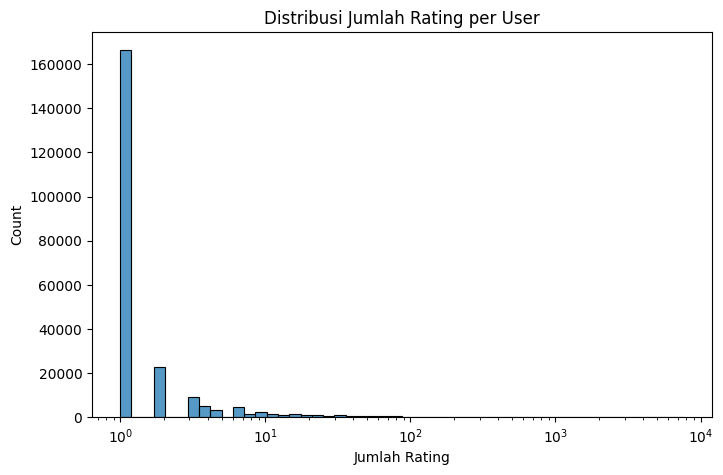

In [50]:
# distribusi jumlah rating per user
user_count = interactions.groupby(
    "user_id"
).size()

plt.figure(figsize=(8,5))

sns.histplot(
    user_count,
    bins=50,
    log_scale=True
)

plt.title(
    "Distribusi Jumlah Rating per User"
)

plt.xlabel("Jumlah Rating")

plt.show()

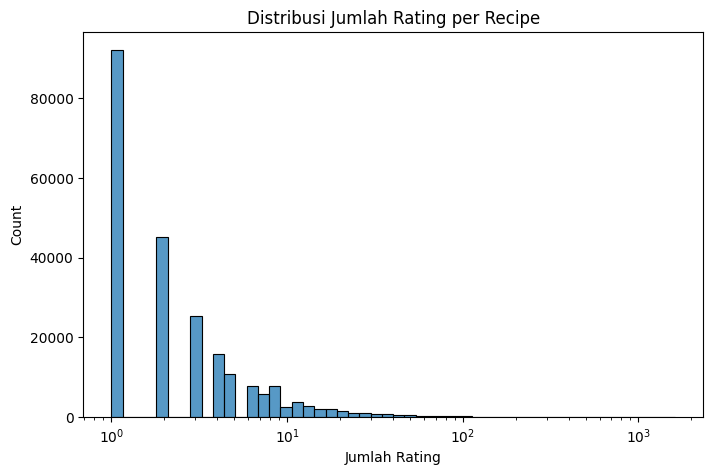

In [51]:
# distribusi jumlah rating per recipe
recipe_count = interactions.groupby(
    "recipe_id"
).size()

plt.figure(figsize=(8,5))

sns.histplot(
    recipe_count,
    bins=50,
    log_scale=True
)

plt.title(
    "Distribusi Jumlah Rating per Recipe"
)

plt.xlabel("Jumlah Rating")

plt.show()

terlihat ada user yang memberi rating ribuan kali dan resep yang menerima rating ribuan kali. terlihat seperti outlier sehingga dibuat boxplot untuk melihat visualisasi keberadaan outlier dan memahami pesebaran datanya.

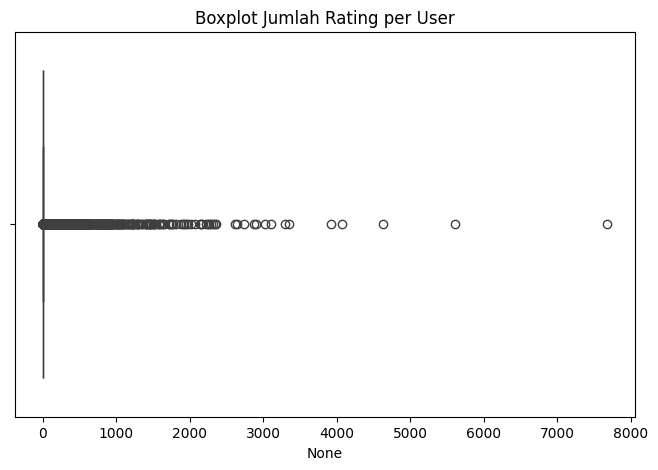

In [52]:
#boxplot jumlah rating per user
plt.figure(figsize=(8,5))

sns.boxplot(
    x=user_count
)

plt.title(
    "Boxplot Jumlah Rating per User"
)

plt.show()

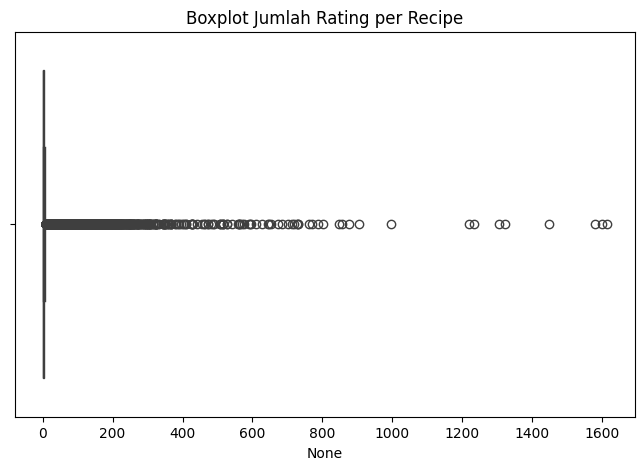

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=recipe_count
)

plt.title(
    "Boxplot Jumlah Rating per Recipe"
)

plt.show()

nilai tersebut bukan noise atau anomali sehingga tidak diperlukan outlier handler. informasi tersebut dapat membuat model mempelajari pola preferensi pengguna.

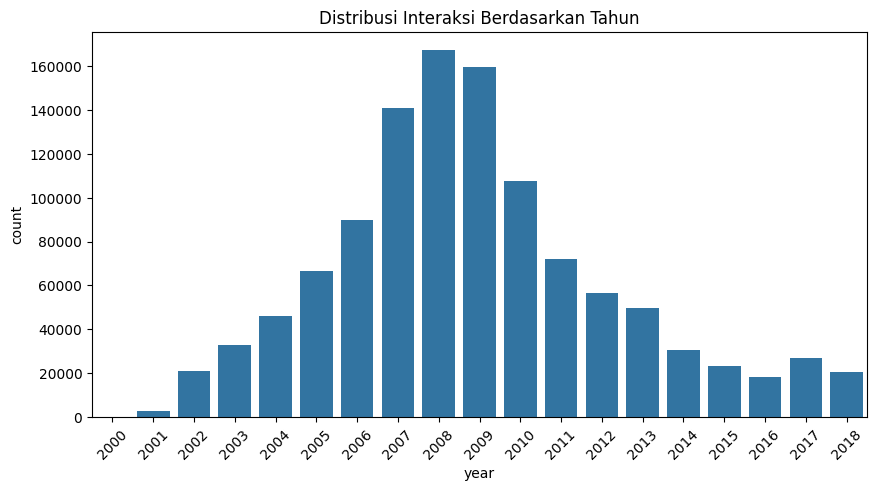

In [54]:
# distribusi interaksi berdasarkan tahun
interactions["date"] = pd.to_datetime(
    interactions["date"]
)

interactions["year"] = interactions[
    "date"
].dt.year

plt.figure(figsize=(10,5))

sns.countplot(
    x="year",
    data=interactions,
    order=sorted(
        interactions["year"].unique()
    )
)

plt.xticks(rotation=45)

plt.title(
    "Distribusi Interaksi Berdasarkan Tahun"
)

plt.show()

In [55]:
# 
n_users = interactions["user_id"].nunique()

n_items = interactions["recipe_id"].nunique()

n_interactions = len(interactions)

sparsity = (
    1 -
    (
        n_interactions /
        (n_users * n_items)
    )
) * 100

print(
    f"Sparsity: {sparsity:.4f}%"
)

Sparsity: 99.9978%


In [56]:
interactions = interactions[
    interactions["rating"] > 0
]

(interactions["rating"] == 0).sum()

np.int64(0)

---
#### feature engineering

##### dataset recipes

Tahap Feature Engineering dilakukan untuk memecah kolom nutrition menjadi 7 indikator zat gizi mandiri (kalori, lemak, gula, sodium, protein, lemak jenuh, dan karbohidrat) serta mengekstrak metrik kuantitas fisik hidangan seperti jumlah tag, jumlah bahan, jumlah langkah, hingga panjang karakter judul dan deskripsi resep, di mana langkah ini sangat urgen untuk mentransformasikan struktur gumpalan teks mentah menjadi sekumpulan matriks prediktor numerik ($X$) yang seragam agar model dapat menghitung bobot kemiripan profil nutrisi dan kompleksitas resep secara akurat

In [57]:
# kalori
df["calories"] = df["nutrition"].apply(
    lambda x: x[0]
)

# nutrisi
df["fat"] = df["nutrition"].apply(
    lambda x: x[1]
)

# gula
df["sugar"] = df["nutrition"].apply(
    lambda x: x[2]
)

# protein
df["protein"] = df["nutrition"].apply(
    lambda x: x[4]
)

#saturated fat
df["saturated_fat"] = df["nutrition"].apply(
    lambda x: x[5]
)

# karbohidrat
df["carbohydrates"] = df["nutrition"].apply(
    lambda x: x[6]
)

# jumlah tag
df["tag_count"] = df["tags"].apply(
    len
)


In [58]:
# cek hasil
print(
    df[
        [
            "name",
            "calories",
            "fat",
            "sugar",
            "protein",
            "saturated_fat",
            "carbohydrates",
            "tag_count",
        ]
    ].head()
)

                                         name  calories   fat  sugar  protein  \
0  arriba   baked winter squash mexican style      51.5   0.0   13.0      2.0   
1            a bit different  breakfast pizza     173.4  18.0    0.0     22.0   
2                   all in the kitchen  chili     269.8  22.0   32.0     39.0   
3                          alouette  potatoes     368.1  17.0   10.0     14.0   
4          amish  tomato ketchup  for canning     352.9   1.0  337.0      3.0   

   saturated_fat  carbohydrates  tag_count  
0            0.0            4.0         20  
1           35.0            1.0         20  
2           27.0            5.0          9  
3            8.0           20.0         30  
4            0.0           28.0         21  


In [59]:
print(type(df["ingredients"].iloc[0]))
print(type(df["tags"].iloc[0]))

<class 'list'>
<class 'list'>


jika tags dan bahan masih berbentuk string, ubah terlebih dahulu menjadi list

In [60]:
# import ast

# recipes["ingredients"] = recipes["ingredients"].apply(
#     ast.literal_eval
# )
# recipes["tags"] = recipes["tags"].apply(
#     ast.literal_eval
# )

# print(type(recipes["ingredients"].iloc[0]))
# print(type(recipes["tags"].iloc[0]))

In [61]:
df["ingredients_text"] = (
    df["ingredients"].apply(lambda x:" ".join(i.replace("_"," ")for i in x)))

df["tags_text"] = (
    df["tags"].apply(lambda x:" ".join(t.replace("_"," ")for t in x)))

In [62]:
df["combined_features"] = (
    df["ingredients_text"]
    + " "
    + df["tags_text"]
)

#### feature prep

##### dataset interaction

In [63]:
ratings = interactions[
    ["user_id", "recipe_id", "rating"]
]

ratings.head()

,user_id,recipe_id,rating
0,38094,40893,4
1,1293707,40893,5
2,8937,44394,4
3,126440,85009,5
4,57222,85009,5


In [64]:
print("Jumlah User :", ratings["user_id"].nunique())
print("Jumlah Recipe :", ratings["recipe_id"].nunique())
print("Jumlah Rating :", len(ratings))

Jumlah User : 196098
Jumlah Recipe : 226590
Jumlah Rating : 1071520


#### encoding

##### dataset recipes

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df["combined_features"]
)

print(tfidf_matrix.shape)

(231636, 4432)


##### dataset interaction

dataset interaction tidak perlu dilakukan encoding karena dataset ini nantinya akan diolah menggunakan metode svd yang memanfaatkan matrix interaksi user_id, recepi_id, dan rating secara langsung untuk membentuk representasi laten pengguna dan item.

#### Scaling
scalling dilakukan untuk menyetarakan skala rentang nilai dari seluruh kolom numerik agar algoritma tidak bias bada fitur yang memiliki angka besar saja.

##### dataset recipes

tahap ini menggunakan standardscaler untuk meredam pencilan ekstrem durasi memasak tanpa merusak variasi pola data resep yang lain. kolom prdiktor dipisah, kemudian dihitung nilai rata-rata dan standar devisiasinya, kemudian seluruh angka dikonversi kedalam skala standar baru

In [66]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients",
    "calories",
    "fat",
    "sugar",
    "protein",
    "saturated_fat",
    "carbohydrates",
    "tag_count"
]

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(
    df_scaled[numeric_cols]
)


##### dataset interaction

pada dataset interaction tidak perlu dilakukan scaling karena atribut user_id dan recipe_id hanya berfungsi sebagai identifier, sedangkan atribut rating telah berada di rentang nilai

#### train test split
data yang ada kemudian dipisah menjadi 80 untuk training dan 20 untuk testing. 80:20 dipilih karena menjadi standar umum dalam pemodelan. parameter random_state=42 disematkan untuk mengunci pengacakan data dan hasil pembagian tetap konsisten

##### dataset recipes

In [67]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df_scaled,
    test_size=0.2,
    random_state=42
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (185308, 22)
Test : (46328, 22)


##### dataset interaction

In [68]:
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(
    ratings[["user_id","recipe_id","rating"]],
    reader
)
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)
print("Jumlah Trainset :", trainset.n_ratings)

print("Jumlah Testset :", len(testset))


Jumlah Trainset : 857216
Jumlah Testset : 214304


#### save csv

In [ ]:
df_scaled.to_csv(
    "food_recommendation_scaaling.csv",
    index=False
)


---
---
---

## Modeling

In [69]:
print("DF")
print(
    df[
        ["minutes","n_steps","n_ingredients"]
    ].head()
)

print("\nDF_SCALED")
print(
    df_scaled[
        ["minutes","n_steps","n_ingredients"]
    ].head()
)

DF
   minutes  n_steps  n_ingredients
0     55.0       11              7
1     30.0        9              6
2    130.0        6             13
3     45.0       11             11
4    190.0        5              8

DF_SCALED
    minutes   n_steps  n_ingredients
0 -0.134409  0.205915      -0.549200
1 -0.337438 -0.127690      -0.816952
2  0.474680 -0.628097       1.057314
3 -0.215620  0.205915       0.521809
4  0.961952 -0.794899      -0.281448


### Content-Based Filtering

##### Cosine Similarity

In [71]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

In [81]:
numeric_features = [
    "minutes",
    "n_ingredients",
    "n_steps",
    "calories",
    "fat",
    "sugar",
    "protein",
    "saturated_fat",
    "carbohydrates"
]

numeric_matrix = df_scaled[
    numeric_features
]


In [73]:
print(tfidf_matrix.shape)
print(numeric_matrix.shape)

(231636, 4432)
(231636, 9)


In [82]:
X_cosine = hstack([
    tfidf_matrix,
    numeric_matrix
]).tocsr()

print(type(X_cosine))
print(X_cosine.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(231636, 4441)


In [83]:
def recommend_cosine(keyword, n=5):

    matches = df[
        df["name"].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        return "Resep tidak ditemukan"

    idx = matches.index[0]

    print("RESEP ACUAN:")
    print(
        df.loc[idx, "name"]
    )

    similarity_scores = cosine_similarity(
        X_cosine[idx:idx+1],
        X_cosine
    )[0]

    similar_idx = (
        similarity_scores
        .argsort()[::-1]
    )

    similar_idx = similar_idx[
        1:n+1
    ]

    result = df.iloc[
        similar_idx
    ][
        [
            "name",
            "minutes",
            "n_steps",
            "n_ingredients",
            "ingredients_text",
            "tags_text"
        ]
    ].copy()

    result[
        "similarity_score"
    ] = (
        similarity_scores[
            similar_idx
        ]
    )

    return result

In [84]:
recommend_cosine(
    "ayam"
)

RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
195586,spicy chicken with coconut lime sauce,55.0,9,15,chicken thighs chicken legs peanut oil green o...,60-minutes-or-less time-to-make course main-in...,0.831476
111414,indonesian style chicken curry,75.0,14,13,coriander seed red chili pepper flakes garlic ...,curries time-to-make course main-ingredient cu...,0.813909
184448,shakuti,90.0,9,15,chicken ghee ground cumin ground coriander who...,time-to-make course main-ingredient cuisine pr...,0.793628
202089,stuffed lemon chicken with basil sauce,55.0,12,15,chicken breasts bacon onion garlic cloves brea...,60-minutes-or-less time-to-make course main-in...,0.791526
42798,chicken and mango curry,45.0,11,16,peanut oil red curry paste garlic coconut milk...,curries 60-minutes-or-less time-to-make course...,0.787862


beat this banana bread bukan resep yang dipilih, tetapi merupakan resep pertama yang ada dalam dataset yang mengandung bread. Kemudian cosine akan membaca resep yang ada dalam resep tersebut berdasarkan bahan (ingredients). Selanjutnya, cosine akan menghitung tingkat similaritas berdasarkan bahan.

bread -> beat this banana bread -> TF-IDF Ingredients -> Cari resep dengan bahan paling mirip

#### K-Nearest Neighbors (KNN)

In [160]:
from sklearn.neighbors import NearestNeighbors

In [161]:
numeric_features = [
    "minutes",
    "n_ingredients",
    "n_steps",
    "calories",
    "fat",
    "sugar",
    "protein",
    "saturated_fat",
    "carbohydrates"
]

numeric_matrix = df_scaled[
    numeric_features
]

In [162]:
X_knn = hstack([
    tfidf_matrix,
    numeric_matrix
]).tocsr()

print(X_knn.shape)

(231636, 4441)


In [163]:
knn = NearestNeighbors(
    n_neighbors=6,
    metric="euclidean"
)

knn.fit(X_knn)

print("Model KNN berhasil dibuat")

Model KNN berhasil dibuat


In [164]:
def recommend_knn(keyword, n=5):

    matches = df[
        df["name"].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        return "Resep tidak ditemukan"

    idx = matches.index[0]

    print("RESEP ACUAN:")
    print(df.loc[idx, "name"])

    distances, indices = knn.kneighbors(
        X_knn[idx:idx+1]
    )

    result = df.iloc[
        indices[0][1:n+1]
    ][
        [
            "name",
            "minutes",
            "n_steps",
            "n_ingredients",
            "ingredients_text",
            "tags_text"
        ]
    ].copy()

    result["distance"] = (
        distances[0][1:n+1]
    )

    return result

In [165]:
recommend_knn("ayam")

RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
210663,thai mussamun curry with chicken potatoes an...,50.0,11,12,unsweetened coconut milk curry paste boneless ...,60-minutes-or-less time-to-make main-ingredien...,1.135723
8590,aromatic chicken curry,50.0,7,12,potatoes peanut oil shallots fresh lemongrass ...,curries 60-minutes-or-less time-to-make course...,1.184639
210370,thai beef with chiles and basil,40.0,10,12,jasmine rice coconut milk coarse salt fish sau...,curries 60-minutes-or-less time-to-make course...,1.208126
98815,grilled drumsticks,80.0,11,12,butter onion ketchup molasses brown sugar worc...,time-to-make course main-ingredient preparatio...,1.212328
128255,madagascar chicken curry,90.0,11,12,boneless chicken breast halves lemon juice oil...,curries time-to-make course main-ingredient cu...,1.226261


### Collaborative Filltering

#### Singular Value Decomposition (SDV)

In [91]:
from surprise import SVD
from surprise import accuracy
from surprise.model_selection import cross_validate


In [92]:
# tunning
factors = [20, 50, 100, 150, 200, 250, 300]

results = []

for f in factors:

    model = SVD(
        n_factors=f,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.02,
        random_state=42
    )

    cv = cross_validate(
        model,
        data,
        measures=['RMSE','MAE'],
        cv=5,
        verbose=False
    )

    rmse = cv['test_rmse'].mean()
    mae = cv['test_mae'].mean()

    results.append([f, rmse, mae])

In [93]:
result_df = pd.DataFrame(
    results,
    columns=[
        "n_factors",
        "RMSE",
        "MAE"
    ]
)

result_df

,n_factors,RMSE,MAE
0,20,0.682231,0.433677
1,50,0.683779,0.434997
2,100,0.685812,0.436789
3,150,0.687869,0.438024
4,200,0.689506,0.439413
5,250,0.691635,0.441157
6,300,0.693224,0.442393


rmse dan mae yg paling kecil adalah yg terbaik. dari hasil tunning, model terbaik diperoleh pada n_factors=20

In [94]:
svd_model = SVD(
    n_factors=20,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model.fit(trainset)

In [95]:
predictions = svd_model.test(testset)

## Evaluasi

In [166]:
import numpy as np

- evaluasi cosine: precision at k (p@k), mean average (map5), coverage
- evaluasi knn: precision at k (p@k), map5, mean distance efficacy
- evaluasi svd: rmse, mae

### content based

In [167]:
test_queries = [
 "banana bread",
 "chocolate cake",
 "chicken curry",
 "pizza",
 "cookies",
 "pasta salad"
]

#### Cosine

In [168]:
for q in test_queries:
    recs = recommend_cosine(q)

    print(q)
    print(recs["name"])

RESEP ACUAN:
beat this  banana bread
banana bread
16384     banana chocolate chip sour cream loaf cake
19733                          beau rive banana cake
92794                              glazed lemon cake
17058                    banana streusel coffee cake
200579        strawberry banana bread   disney world
Name: name, dtype: object
RESEP ACUAN:
100 chocolate cake
chocolate cake
69853     date cookies  grandma cookies
161975           polish applesauce cake
113943                         jam cake
138137             mom s chocolate cake
55585                   coconut cookies
Name: name, dtype: object
RESEP ACUAN:
creamy  chicken curry
chicken curry
65756               crock pot creamy beef curry
127390    lubbers jerk chicken with peach salsa
139264         moroccan chicken stew  crock pot
20907          beef with cauliflower  crock pot
188847                slow cooker chicken chili
Name: name, dtype: object
RESEP ACUAN:
a bit different  breakfast pizza
pizza
159133      philade

In [169]:
def check_relevance(query, row):

    query_words = query.lower().split()

    text = (
        str(row["name"]) + " " +
        str(row["ingredients_text"]) + " " +
        str(row["tags_text"])
    ).lower()

    return any(
        word in text
        for word in query_words
    )

In [170]:
def precision_at_k(query, recommendations):

    relevances = [
        check_relevance(query, row)
        for _, row in recommendations.iterrows()
    ]

    return np.mean(relevances)

In [171]:
def average_precision(query, recommendations):

    relevances = np.array([
        check_relevance(query, row)
        for _, row in recommendations.iterrows()
    ])

    precisions = []

    for i in range(len(relevances)):

        if relevances[i]:

            precisions.append(
                relevances[:i+1].sum() / (i+1)
            )

    if len(precisions) == 0:
        return 0

    return np.mean(precisions)

In [172]:
precision_scores = []
ap_scores = []

for query in test_queries:

    recs = recommend_cosine(
        query,
        n=5
    )

    p = precision_at_k(
        query,
        recs
    )

    ap = average_precision(
        query,
        recs
    )

    precision_scores.append(p)
    ap_scores.append(ap)

    print(
        f"{query} | P@5={p:.3f} | AP={ap:.3f}"
    )

RESEP ACUAN:
beat this  banana bread
banana bread | P@5=0.800 | AP=0.887
RESEP ACUAN:
100 chocolate cake
chocolate cake | P@5=0.600 | AP=0.639
RESEP ACUAN:
creamy  chicken curry
chicken curry | P@5=0.800 | AP=0.950
RESEP ACUAN:
a bit different  breakfast pizza
pizza | P@5=1.000 | AP=1.000
RESEP ACUAN:
1 in canada chocolate chip cookies
cookies | P@5=0.600 | AP=0.917
RESEP ACUAN:
italian sandwich  pasta salad
pasta salad | P@5=0.800 | AP=0.950


In [173]:
map_score = np.mean(
    ap_scores
)

print(
    f"MAP@5 = {map_score:.4f}"
)

MAP@5 = 0.8905


In [174]:
recommended_recipes = set()

for query in test_queries:

    recs = recommend_cosine(
        query,
        n=5
    )

    recommended_recipes.update(
        recs["name"]
    )

RESEP ACUAN:
beat this  banana bread
RESEP ACUAN:
100 chocolate cake
RESEP ACUAN:
creamy  chicken curry
RESEP ACUAN:
a bit different  breakfast pizza
RESEP ACUAN:
1 in canada chocolate chip cookies
RESEP ACUAN:
italian sandwich  pasta salad


In [175]:
coverage = (
    len(recommended_recipes)
    /
    len(df)
)

print(
    f"Coverage = {coverage:.4f}"
)

Coverage = 0.0001


In [176]:
print(
    f"Precision@5 = {np.mean(precision_scores):.4f}"
)

print(
    f"MAP@5 = {map_score:.4f}"
)

print(
    f"Coverage = {coverage:.4f}"
)

Precision@5 = 0.7667
MAP@5 = 0.8905
Coverage = 0.0001


#### KNN

In [177]:
precision_scores = []
ap_scores = []

for query in test_queries:

    recs = recommend_knn(
        query,
        n=5
    )

    p = precision_at_k(
        query,
        recs
    )

    ap = average_precision(
        query,
        recs
    )

    precision_scores.append(p)
    ap_scores.append(ap)

    print(
        f"{query} | P@5={p:.3f} | AP={ap:.3f}"
    )

map_score = np.mean(
    ap_scores
)

print(
    f"MAP@5 = {map_score:.4f}"
)

RESEP ACUAN:
beat this  banana bread
banana bread | P@5=1.000 | AP=1.000
RESEP ACUAN:
100 chocolate cake
chocolate cake | P@5=0.600 | AP=1.000
RESEP ACUAN:
creamy  chicken curry
chicken curry | P@5=1.000 | AP=1.000
RESEP ACUAN:
a bit different  breakfast pizza
pizza | P@5=1.000 | AP=1.000
RESEP ACUAN:
1 in canada chocolate chip cookies
cookies | P@5=0.600 | AP=0.867
RESEP ACUAN:
italian sandwich  pasta salad
pasta salad | P@5=1.000 | AP=1.000
MAP@5 = 0.9778


In [178]:
distance_scores = []

for query in test_queries:

    matches = df[
        df["name"].str.contains(
            query,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        continue

    idx = matches.index[0]

    distances, indices = knn.kneighbors(
        X_knn[idx:idx+1]
    )

    distance_scores.extend(
        distances[0][1:]
    )

mean_distance = np.mean(
    distance_scores
)

print(
    f"Mean Distance = {mean_distance:.4f}"
)

Mean Distance = 1.1978


In [179]:
print(
    f"Precision@5 = {np.mean(precision_scores):.4f}"
)

print(
    f"MAP@5 = {map_score:.4f}"
)

print(
    f"Mean Distance = {mean_distance:.4f}"
)

Precision@5 = 0.8667
MAP@5 = 0.9778
Mean Distance = 1.1978


### collab fillter (SVD)

In [180]:
## contoh hasil prediksi
for pred in predictions[:5]:

    print("User ID :", pred.uid)
    print("Recipe ID :", pred.iid)
    print("Actual Rating :", pred.r_ui)
    print("Predicted Rating :", round(pred.est,2))
    print("-"*30)

User ID : 106624
Recipe ID : 206093
Actual Rating : 5.0
Predicted Rating : 4.78
------------------------------
User ID : 29268
Recipe ID : 43138
Actual Rating : 5.0
Predicted Rating : 4.73
------------------------------
User ID : 2000244134
Recipe ID : 349246
Actual Rating : 5.0
Predicted Rating : 4.17
------------------------------
User ID : 105601
Recipe ID : 220872
Actual Rating : 5.0
Predicted Rating : 4.79
------------------------------
User ID : 594139
Recipe ID : 218006
Actual Rating : 5.0
Predicted Rating : 4.81
------------------------------


In [181]:
from surprise import accuracy

## rmse
rmse = accuracy.rmse(predictions)

## mae
mae =  accuracy.mae(predictions)

RMSE: 0.6841
MAE:  0.4341


In [182]:
evaluation = pd.DataFrame({

    "Metric":[
        "RMSE",
        "MAE"
    ],

    "Value":[
        rmse,
        mae
    ]

})

evaluation

,Metric,Value
0,RMSE,0.684135
1,MAE,0.434068


## Recomendation Generation (content based)

### Content based

In [183]:
print("COSINE")
display(
    recommend_cosine("pizza")
)

print("KNN")
display(
    recommend_knn("pizza")
)

COSINE
RESEP ACUAN:
a bit different  breakfast pizza


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
159133,philadelphia style velveeta pizza,35.0,6,4,prepared pizza crust mozzarella cheese prepare...,60-minutes-or-less time-to-make course main-in...,0.779694
82769,favorite bbq chicken pizza,22.0,9,6,chicken breasts barbecue sauce onion green pep...,30-minutes-or-less time-to-make course main-in...,0.775161
158407,perfect pepperoni pizza pie,20.0,6,4,prepared pizza crust pizza sauce pepperoni pro...,weeknight 30-minutes-or-less time-to-make cour...,0.768016
75459,easy cheese pizza,33.0,9,5,pizza dough olive oil prepared pizza sauce moz...,60-minutes-or-less time-to-make course main-in...,0.767499
4666,amazing ny style white garlic pizza,27.0,8,5,pizza crust italian sausage garlic alfredo sau...,30-minutes-or-less time-to-make course main-in...,0.762413


KNN
RESEP ACUAN:
a bit different  breakfast pizza


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
112991,italian sausage onion pizza,25.0,9,6,sausage bell pepper pizza sauce prepared pizza...,30-minutes-or-less time-to-make course prepara...,0.980013
82769,favorite bbq chicken pizza,22.0,9,6,chicken breasts barbecue sauce onion green pep...,30-minutes-or-less time-to-make course main-in...,0.991224
168055,quick easy healthy mixed seafood pizza,20.0,8,7,pizza crust olive oil pizza sauce seafood garl...,30-minutes-or-less time-to-make course main-in...,1.004207
190075,smoky barbecue chicken pizza,45.0,8,6,prepared pizza crust colby-monterey jack chees...,60-minutes-or-less time-to-make course main-in...,1.024953
200265,stove top skillet pizza,20.0,8,6,pizza crust mix pizza sauce pepperoni green pe...,30-minutes-or-less time-to-make course prepara...,1.046969


In [184]:
print("COSINE")
display(
    recommend_cosine("banana bread")
)

print("KNN")
display(
    recommend_knn("banana bread")
)

COSINE
RESEP ACUAN:
beat this  banana bread


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
16384,banana chocolate chip sour cream loaf cake,100.0,14,12,butter sugar eggs salt baking powder baking so...,time-to-make course main-ingredient preparatio...,0.972371
19733,beau rive banana cake,35.0,11,11,golden raisin rum all-purpose flour baking pow...,60-minutes-or-less time-to-make course main-in...,0.971539
92794,glazed lemon cake,80.0,12,10,butter granulated sugar eggs flour baking soda...,weeknight time-to-make course main-ingredient ...,0.971491
17058,banana streusel coffee cake,65.0,15,11,butter sugar eggs vanilla half-and-half cream ...,time-to-make course main-ingredient preparatio...,0.971161
200579,strawberry banana bread disney world,75.0,11,8,butter granulated sugar bananas eggs salt baki...,time-to-make course main-ingredient preparatio...,0.970609


KNN
RESEP ACUAN:
beat this  banana bread


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
200579,strawberry banana bread disney world,75.0,11,8,butter granulated sugar bananas eggs salt baki...,time-to-make course main-ingredient preparatio...,1.087197
16212,banana bread disneyland resort,75.0,9,9,butter vanilla extract sugar flour eggs salt w...,time-to-make course main-ingredient preparatio...,1.103988
131167,mark bittman s banana bread,70.0,10,10,all-purpose flour whole wheat flour salt bakin...,time-to-make course main-ingredient preparatio...,1.124821
6888,apple loaf,65.0,12,10,all-purpose flour baking powder baking soda sa...,weeknight time-to-make course main-ingredient ...,1.135081
82123,fantastic orange loaf,75.0,11,10,butter sugar eggs orange rind fresh orange jui...,time-to-make course main-ingredient preparatio...,1.142677


In [185]:
print("COSINE")
display(
    recommend_cosine("ayam")
)

print("KNN")
display(
    recommend_knn("ayam")
)

COSINE
RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,similarity_score
195586,spicy chicken with coconut lime sauce,55.0,9,15,chicken thighs chicken legs peanut oil green o...,60-minutes-or-less time-to-make course main-in...,0.831476
111414,indonesian style chicken curry,75.0,14,13,coriander seed red chili pepper flakes garlic ...,curries time-to-make course main-ingredient cu...,0.813909
184448,shakuti,90.0,9,15,chicken ghee ground cumin ground coriander who...,time-to-make course main-ingredient cuisine pr...,0.793628
202089,stuffed lemon chicken with basil sauce,55.0,12,15,chicken breasts bacon onion garlic cloves brea...,60-minutes-or-less time-to-make course main-in...,0.791526
42798,chicken and mango curry,45.0,11,16,peanut oil red curry paste garlic coconut milk...,curries 60-minutes-or-less time-to-make course...,0.787862


KNN
RESEP ACUAN:
ayam bali  balinese chicken


,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
210663,thai mussamun curry with chicken potatoes an...,50.0,11,12,unsweetened coconut milk curry paste boneless ...,60-minutes-or-less time-to-make main-ingredien...,1.135723
8590,aromatic chicken curry,50.0,7,12,potatoes peanut oil shallots fresh lemongrass ...,curries 60-minutes-or-less time-to-make course...,1.184639
210370,thai beef with chiles and basil,40.0,10,12,jasmine rice coconut milk coarse salt fish sau...,curries 60-minutes-or-less time-to-make course...,1.208126
98815,grilled drumsticks,80.0,11,12,butter onion ketchup molasses brown sugar worc...,time-to-make course main-ingredient preparatio...,1.212328
128255,madagascar chicken curry,90.0,11,12,boneless chicken breast halves lemon juice oil...,curries time-to-make course main-ingredient cu...,1.226261


### collab filter

In [186]:
all_recipe_ids = df["id"].unique()

In [187]:
def recommend_svd(user_id, n=5):

    predictions = []

    for recipe_id in all_recipe_ids:

        pred = svd_model.predict(
            uid=user_id,
            iid=recipe_id
        )

        predictions.append(
            (recipe_id, pred.est)
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_n = predictions[:n]

    return pd.DataFrame(
        top_n,
        columns=[
            "recipe_id",
            "predicted_rating"
        ]
    )

In [188]:
top_n = recommend_svd(
    user_id=122877,
    n=20
)

In [189]:
top_n = top_n.merge(

    df[
        ["id","name"]
    ],

    left_on="recipe_id",
    right_on="id",
    how="left"

)

top_n[
    ["name","predicted_rating"]
]

,name,predicted_rating
0,caprese salad tomatoes italian marinated toma...,4.966744
1,foolproof standing prime rib roast paula deen,4.944101
2,couscous jambalaya,4.938690
3,barb s gumbo,4.937205
4,asian cole slaw,4.934712
5,southwestern grilled chicken with lime butter,4.932788
6,popcorn stove top,4.931267
7,blueberry sour cream pie,4.926077
8,szechuan style eggplant aubergine,4.925991
9,jalapeno pepper jelly chicken,4.924003


In [190]:
interactions[
    interactions["user_id"] == 122877
]["rating"].value_counts()

rating
5    121
4     36
3     15
2      2
Name: count, dtype: int64

## Visualisasi

#### cosine

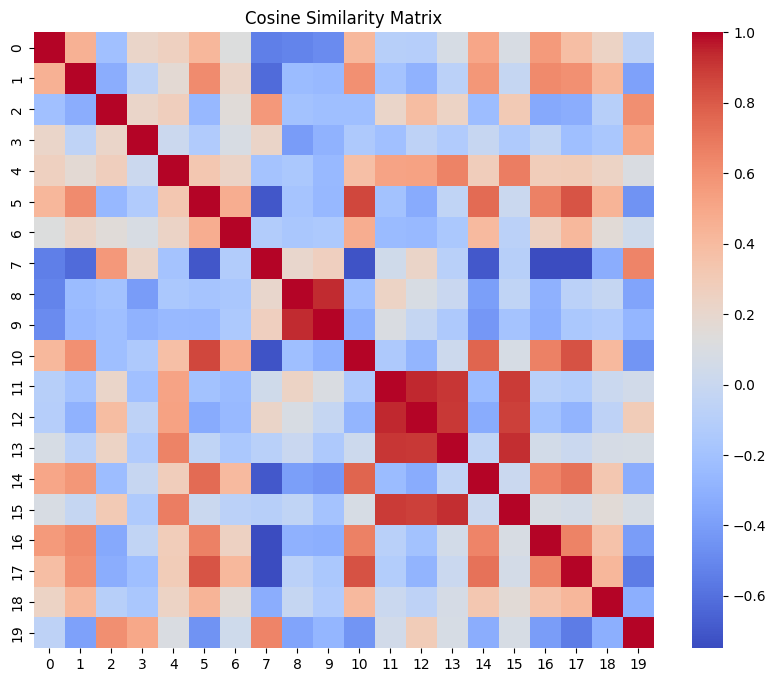

In [123]:
# matrix cosine similarity matrix
sample_sim = cosine_similarity(
    X_cosine[:20]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    sample_sim,
    cmap="coolwarm"
)

plt.title(
    "Cosine Similarity Matrix"
)

plt.show()


RESEP ACUAN:
a bit different  breakfast pizza


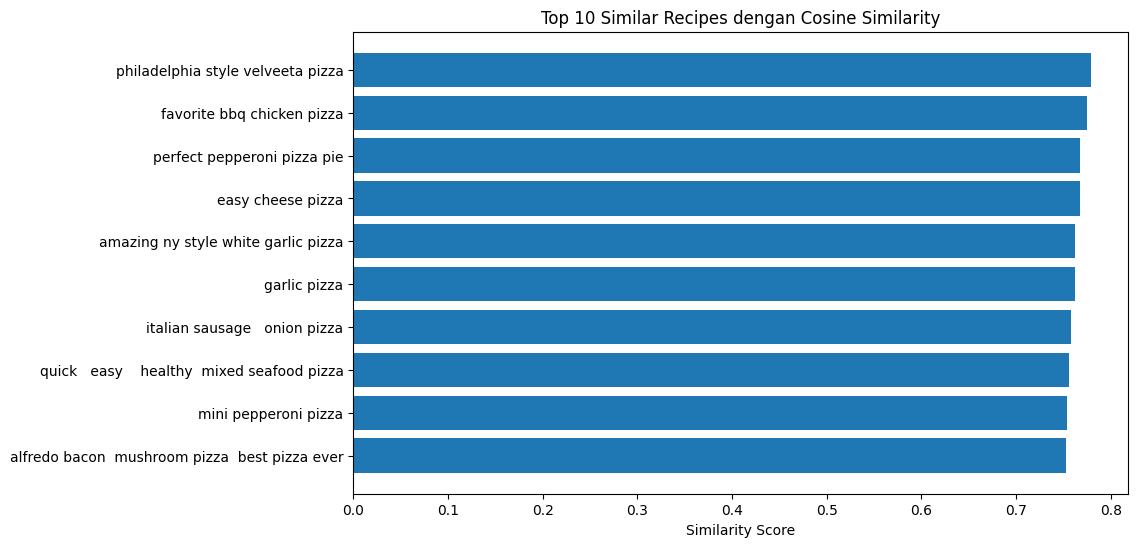

In [124]:
# top 10 similarity recipes (cosine)
cosine_rec = recommend_cosine(
    "pizza",
    n=10
)

plt.figure(figsize=(10,6))

plt.barh(

    cosine_rec["name"],

    cosine_rec["similarity_score"]

)

plt.xlabel(
    "Similarity Score"
)

plt.title(
    "Top 10 Similar Recipes dengan Cosine Similarity"
)

plt.gca().invert_yaxis()

plt.show()

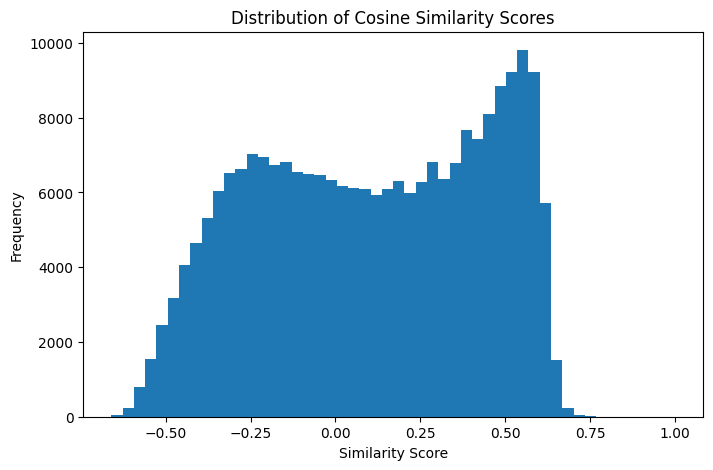

In [125]:
# distribusi similarity score
matches = df[
    df["name"].str.contains(
        "pizza",
        case=False,
        na=False
    )
]

idx = matches.index[0]

similarity_scores = cosine_similarity(
    X_cosine[idx:idx+1],
    X_cosine
)[0]

plt.figure(figsize=(8,5))

plt.hist(
    similarity_scores,
    bins=50
)

plt.title(
    "Distribution of Cosine Similarity Scores"
)

plt.xlabel(
    "Similarity Score"
)

plt.ylabel(
    "Frequency"
)

plt.show()

#### knn

RESEP ACUAN:
a bit different  breakfast pizza
RESEP ACUAN:
a bit different  breakfast pizza


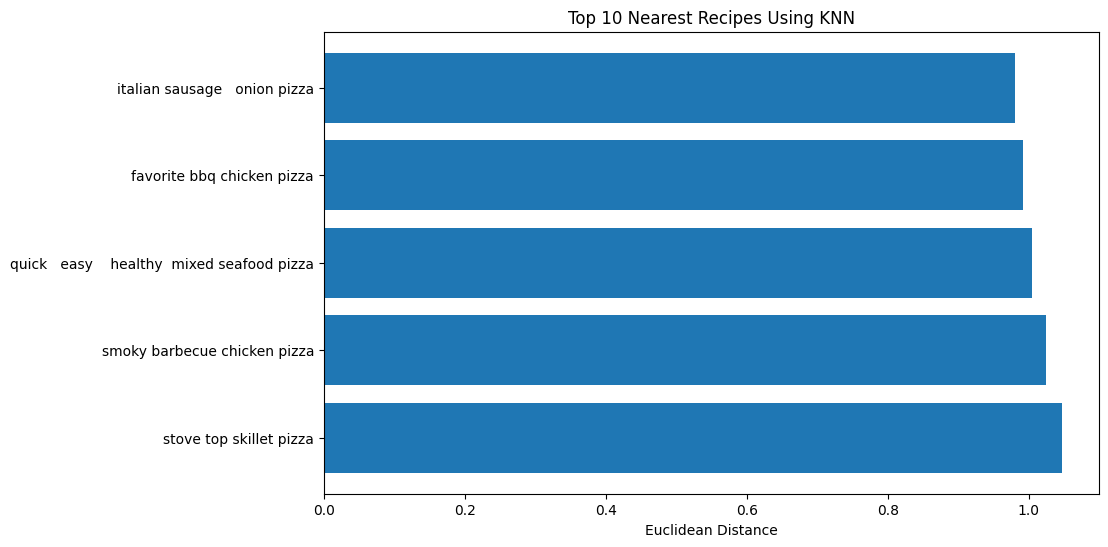

In [126]:
# top 10 resep terdekat (knn)
knn_rec = recommend_knn(
    "pizza",
    n=10
)

knn_rec

knn_rec = recommend_knn(
    "pizza",
    n=10
)

plt.figure(figsize=(10,6))

plt.barh(

    knn_rec["name"],

    knn_rec["distance"]

)

plt.xlabel(
    "Euclidean Distance"
)

plt.title(
    "Top 10 Nearest Recipes Using KNN"
)

plt.gca().invert_yaxis()

plt.show()

RESEP ACUAN:
a bit different  breakfast pizza


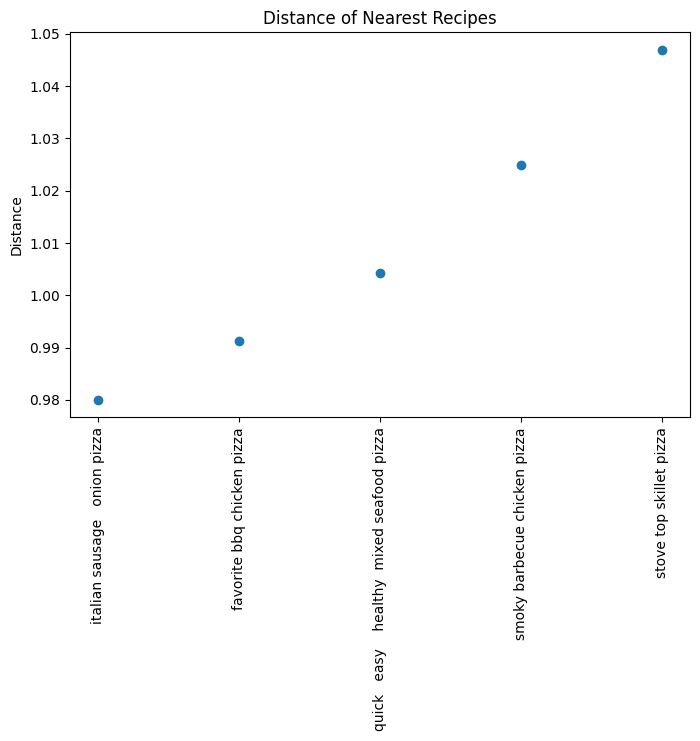

In [127]:
# distance score
knn_rec = recommend_knn(
    "pizza",
    n=10
)

plt.figure(figsize=(8,5))

plt.scatter(

    range(len(knn_rec)),

    knn_rec["distance"]

)

plt.xticks(
    range(len(knn_rec)),
    knn_rec["name"],
    rotation=90
)

plt.ylabel(
    "Distance"
)

plt.title(
    "Distance of Nearest Recipes"
)

plt.show()

,name,minutes,n_steps,n_ingredients,ingredients_text,tags_text,distance
112991,italian sausage onion pizza,25.0,9,6,sausage bell pepper pizza sauce prepared pizza...,30-minutes-or-less time-to-make course prepara...,0.980013
82769,favorite bbq chicken pizza,22.0,9,6,chicken breasts barbecue sauce onion green pep...,30-minutes-or-less time-to-make course main-in...,0.991224
168055,quick easy healthy mixed seafood pizza,20.0,8,7,pizza crust olive oil pizza sauce seafood garl...,30-minutes-or-less time-to-make course main-in...,1.004207
190075,smoky barbecue chicken pizza,45.0,8,6,prepared pizza crust colby-monterey jack chees...,60-minutes-or-less time-to-make course main-in...,1.024953
200265,stove top skillet pizza,20.0,8,6,pizza crust mix pizza sauce pepperoni green pe...,30-minutes-or-less time-to-make course prepara...,1.046969


<BarContainer object of 5 artists>

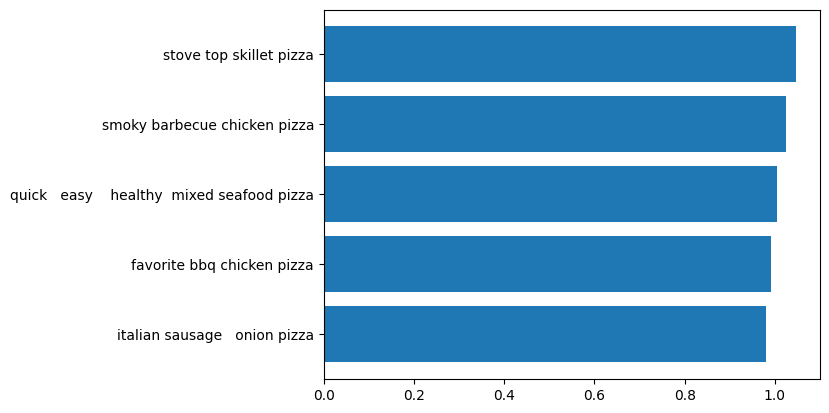

In [128]:
display(knn_rec)
plt.barh(
    knn_rec["name"],
    knn_rec["distance"]
)

#### sdv

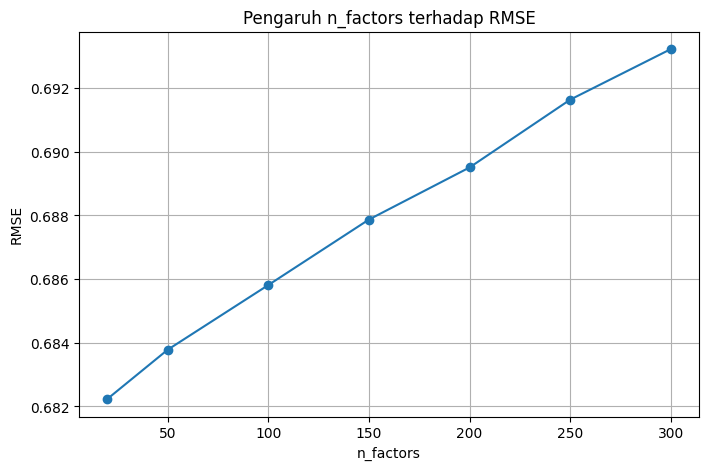

In [129]:
# grafik hasil tunning (svd)
plt.figure(figsize=(8,5))

plt.plot(
    result_df["n_factors"],
    result_df["RMSE"],
    marker="o"
)

plt.xlabel("n_factors")
plt.ylabel("RMSE")
plt.title("Pengaruh n_factors terhadap RMSE")

plt.grid(True)

plt.show()

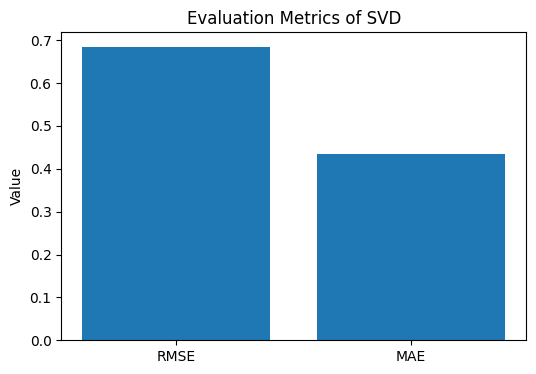

In [130]:
# grafik evaluasi
metrics = ["RMSE","MAE"]

values = [
    rmse,
    mae
]

plt.figure(figsize=(6,4))

plt.bar(
    metrics,
    values
)

plt.ylabel("Value")

plt.title(
    "Evaluation Metrics of SVD"
)

plt.show()

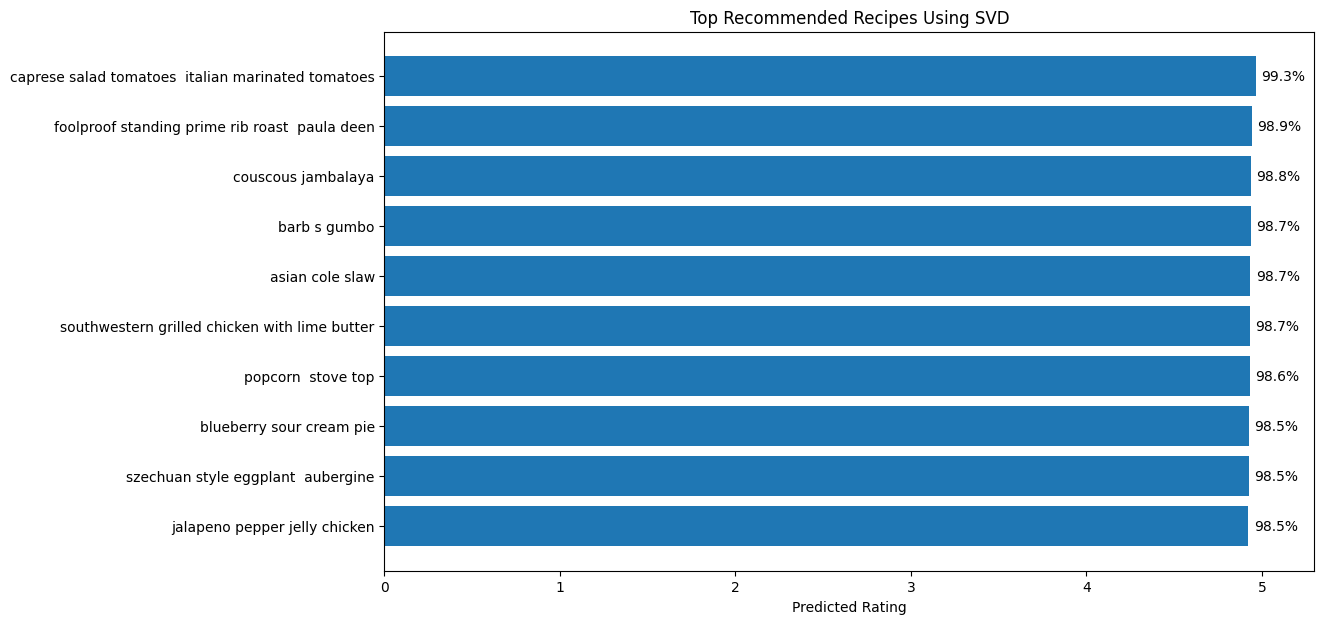

In [131]:
plt.figure(figsize=(12,7))

bars = plt.barh(

    top_n["name"][:10],

    top_n["predicted_rating"][:10]

)

plt.xlabel(
    "Predicted Rating"
)

plt.title(
    "Top Recommended Recipes Using SVD"
)

plt.xlim(0,5.3)

for bar in bars:

    width = bar.get_width()

    percent = width / 5 * 100

    plt.text(

        width + 0.03,

        bar.get_y() + bar.get_height()/2,

        f"{percent:.1f}%",

        va="center"

    )

plt.gca().invert_yaxis()

plt.show()